# Import Libraries

In [40]:
import numpy as np
import pandas as pd 

### Data loading

In [41]:
# For SKUs starting with '90'
# Data loading
df = pd.read_csv('../data/ForecastDataset_from_2016_to_2025_for_SKUs_started_with_90.csv')

In [42]:
df.shape

(533948, 9)

In [43]:
df.head()

,ProductFamily,Order_ID,OrderDate,SKU_Description,WareHouseQuantity,SKU,SKU_Category,Channel,ShipToState
0,AIRD,62181848,12/19/2022,Air Doctor AD3000,1,90AD01AD01,Cross Sell,SEM_Radial,VA
1,AIRD,60849149,7/8/2021,Air Doctor AD1000 Tower,1,90AD01AT01-W,Unit,DIG_OTHER_Radial,PA
2,AIRD,60849335,7/8/2021,Air Doctor AD3000,1,90AD01AD01,Cross Sell,WEB_Radial,OR
3,AIRD,60849349,7/8/2021,Air Doctor AD3000,1,90AD01AD01,Cross Sell,WEB_Radial,MT
4,AIRD,60849449,7/8/2021,Air Doctor AD3000,1,90AD01AD01,Cross Sell,DIG_INFLCR_Radial,MD


In [44]:
df.columns

Index(['ProductFamily', 'Order_ID', 'OrderDate', 'SKU_Description',
       'WareHouseQuantity', 'SKU', 'SKU_Category', 'Channel', 'ShipToState'],
      dtype='object')

In [45]:
df.nunique()

ProductFamily             1
Order_ID             479881
OrderDate              3103
SKU_Description          20
WareHouseQuantity        13
SKU                      21
SKU_Category              3
Channel                  34
ShipToState              88
dtype: int64

In [46]:
df.isna().sum()

ProductFamily          0
Order_ID               0
OrderDate              0
SKU_Description      544
WareHouseQuantity      0
SKU                    0
SKU_Category         544
Channel               12
ShipToState           92
dtype: int64

In [47]:
df.dropna(inplace=True)

In [48]:
df.shape

(533300, 9)

### Feature Engineering

In [49]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['Week'] = df['OrderDate'].dt.to_period('W').apply(lambda r: r.start_time)
df['Month'] = df['OrderDate'].dt.month
df['Year'] = df['OrderDate'].dt.year

In [50]:
df.head()

,ProductFamily,Order_ID,OrderDate,SKU_Description,WareHouseQuantity,SKU,SKU_Category,Channel,ShipToState,Week,Month,Year
0,AIRD,62181848,2022-12-19,Air Doctor AD3000,1,90AD01AD01,Cross Sell,SEM_Radial,VA,2022-12-19,12,2022
1,AIRD,60849149,2021-07-08,Air Doctor AD1000 Tower,1,90AD01AT01-W,Unit,DIG_OTHER_Radial,PA,2021-07-05,7,2021
2,AIRD,60849335,2021-07-08,Air Doctor AD3000,1,90AD01AD01,Cross Sell,WEB_Radial,OR,2021-07-05,7,2021
3,AIRD,60849349,2021-07-08,Air Doctor AD3000,1,90AD01AD01,Cross Sell,WEB_Radial,MT,2021-07-05,7,2021
4,AIRD,60849449,2021-07-08,Air Doctor AD3000,1,90AD01AD01,Cross Sell,DIG_INFLCR_Radial,MD,2021-07-05,7,2021


### Range Of SKU's

In [51]:
def print_date_ranges(df, sku_list=None):
    """
    Prints the overall dataset date range and individual date ranges for specified SKUs.

    Parameters:
    df (pd.DataFrame): DataFrame containing at least 'OrderDate' and 'SKU' columns.
    sku_list (list, optional): List of SKU strings to check date ranges for.
    """
    print("Full dataset date range:", df['OrderDate'].min(), "to", df['OrderDate'].max())
    
    if sku_list:
        for sku in sku_list:
            df_sku_check = df[df['SKU'] == sku]
            if not df_sku_check.empty:
                print(f"Selected SKU date range {sku}:", df_sku_check['OrderDate'].min(), "to", df_sku_check['OrderDate'].max())
                # print(f"Total weekly data points for this SKU: {df_sku_check.shape[0]}")
            else:
                print(f"No data found for SKU: {sku}")
                


In [52]:
sku_list = ['90AD350AD01', '90AD200AD01', '90AD01AT01-W', '90AD02AD01', '90AD550AD01']
print_date_ranges(df, sku_list)


Full dataset date range: 2016-12-23 00:00:00 to 2025-07-29 00:00:00
Selected SKU date range 90AD350AD01: 2022-09-15 00:00:00 to 2025-07-29 00:00:00
Selected SKU date range 90AD200AD01: 2022-06-04 00:00:00 to 2025-07-28 00:00:00
Selected SKU date range 90AD01AT01-W: 2019-08-16 00:00:00 to 2025-07-28 00:00:00
Selected SKU date range 90AD02AD01: 2021-05-25 00:00:00 to 2023-06-30 00:00:00
Selected SKU date range 90AD550AD01: 2022-09-15 00:00:00 to 2025-07-28 00:00:00


### Data Splitting: Training and Testing (For Checking Accuracy)
- For Testing : April, May, June 2025
- For Training : Sep 22 to March 31

In [53]:
import pandas as pd
from dateutil.relativedelta import relativedelta


# Convert OrderDate to datetime
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

# Create 'Week' column as week start date (Monday)
df['Week'] = df['OrderDate'].dt.to_period('W').apply(lambda r: r.start_time)

# Group weekly by SKU
weekly_by_sku = df.groupby(['Week', 'SKU'])['WareHouseQuantity'].sum().reset_index()

# Filter for the specific SKU
sku = '90AD350AD01'
# sku = '90AD200AD01'
df_sku_weekly = weekly_by_sku[weekly_by_sku['SKU'] == sku][['Week', 'WareHouseQuantity']].copy()

# Add week start and end dates
df_sku_weekly['Week_Start'] = df_sku_weekly['Week']
df_sku_weekly['Week_End'] = df_sku_weekly['Week_Start'] + pd.Timedelta(days=6)

# -----------------------
# Split Test & Train
# -----------------------

# Test Data: June 2025
test_data = df_sku_weekly[
    (df_sku_weekly['Week_Start'] >= pd.to_datetime('2025-06-01')) &
    (df_sku_weekly['Week_Start'] < pd.to_datetime('2025-07-01'))
]

# Train Data: Before June 2025
train_data = df_sku_weekly[
    df_sku_weekly['Week_Start'] < pd.to_datetime('2025-06-01')
]


# -----------------------
# TRAIN DATA RANGE INFO
# -----------------------
# STEP 0: Print Training & Testing Period Info
train_start = train_data['Week_Start'].min()
train_end = train_data['Week_Start'].max()
test_start = test_data['Week_Start'].min()
test_end = test_data['Week_Start'].max()

# Compute durations
train_months = (train_end.to_period('M') - train_start.to_period('M')).n + 1
train_years = (train_end.to_period('Y') - train_start.to_period('Y')).n + 1
train_weeks = train_data['Week_Start'].nunique()

test_months = (test_end.to_period('M') - test_start.to_period('M')).n + 1
test_years = (test_end.to_period('Y') - test_start.to_period('Y')).n + 1
test_weeks = test_data['Week_Start'].nunique()

print(f"\nTraining Data Range: {train_start.date()} to {train_end.date()}")
print(f" - Total Years:  {train_years}")
print(f" - Total Months: {train_months}")
print(f" - Total Weeks:  {train_weeks}")

print(f"\nTesting Data Range:  {test_start.date()} to {test_end.date()}")
print(f" - Total Years:  {test_years}")
print(f" - Total Months: {test_months}")
print(f" - Total Weeks:  {test_weeks}")


print("\nTrain Data:")
print(train_data[['Week_Start', 'Week_End', 'WareHouseQuantity']].head(-1))

print("\nTest Data:")
print(test_data[['Week_Start', 'Week_End', 'WareHouseQuantity']].head(-1))




Training Data Range: 2022-09-12 to 2025-05-26
 - Total Years:  4
 - Total Months: 33
 - Total Weeks:  139

Testing Data Range:  2025-06-02 to 2025-06-30
 - Total Years:  1
 - Total Months: 1
 - Total Weeks:  5

Train Data:
     Week_Start   Week_End  WareHouseQuantity
786  2022-09-12 2022-09-18                  1
801  2022-09-26 2022-10-02                  5
821  2022-10-17 2022-10-23                 17
831  2022-10-24 2022-10-30                 84
842  2022-10-31 2022-11-06                125
...         ...        ...                ...
1968 2025-04-21 2025-04-27                541
1978 2025-04-28 2025-05-04                509
1987 2025-05-05 2025-05-11                506
1996 2025-05-12 2025-05-18                486
2005 2025-05-19 2025-05-25                318

[138 rows x 3 columns]

Test Data:
     Week_Start   Week_End  WareHouseQuantity
2027 2025-06-02 2025-06-08                375
2037 2025-06-09 2025-06-15                474
2047 2025-06-16 2025-06-22                475
2056

In [54]:
df.columns

Index(['ProductFamily', 'Order_ID', 'OrderDate', 'SKU_Description',
       'WareHouseQuantity', 'SKU', 'SKU_Category', 'Channel', 'ShipToState',
       'Week', 'Month', 'Year'],
      dtype='object')

### LSTM Model

In [55]:
# pip install tensorflow

In [56]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ----- STEP 1: Prepare Data -----
# Assume train_data and test_data are already defined with columns ['Week_Start', 'Week_End', 'WareHouseQuantity']
df = pd.concat([train_data, test_data]).reset_index(drop=True)

# Normalize target column
scaler = MinMaxScaler()
scaled_quantity = scaler.fit_transform(df[['WareHouseQuantity']])

# ----- STEP 2: Create Sequences -----
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)

sequence_length = 4
X_all, y_all = create_sequences(scaled_quantity, sequence_length)

# Align time indexes
time_data = df.iloc[sequence_length:].reset_index(drop=True)
X_train = X_all[:len(train_data) - sequence_length]
y_train = y_all[:len(train_data) - sequence_length]
X_test = X_all[len(train_data) - sequence_length:]
y_test = y_all[len(train_data) - sequence_length:]

# Reshape for LSTM
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# ----- STEP 3: Build LSTM Model -----
model = Sequential()
model.add(LSTM(128, input_shape=(X_train.shape[1], 1), return_sequences=False))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

# ----- STEP 4: Train -----
model.fit(X_train, y_train, epochs=200, batch_size=8, verbose=1)

# ----- STEP 5: Predict -----
y_pred_scaled = model.predict(X_test)
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_test)

# ----- STEP 6: Evaluation -----
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
print("R2 Score:", r2_score(y_true, y_pred))

# ----- STEP 7: Result DataFrame -----
# Extract Start and End week for each prediction
start_weeks = test_data['Week_Start'].iloc[:len(y_true)].reset_index(drop=True)
end_weeks = test_data['Week_End'].iloc[:len(y_true)].reset_index(drop=True)

actuals = pd.Series(y_true.flatten()).reset_index(drop=True)
predicted = pd.Series(np.round(y_pred.flatten()).astype(int)).reset_index(drop=True)
difference = predicted - actuals
percent_diff = ((difference / actuals) * 100).round(2)
minus_10 = (actuals * 0.9).round(2)
plus_10 = (actuals * 1.1).round(2)
within_10 = (predicted >= minus_10) & (predicted <= plus_10)
status = within_10.map({True: "Acceptable", False: "Out of Range"})



result_df = pd.DataFrame({
    'Start_Week': start_weeks,
    'End_Week': end_weeks,
    'Actual_WareHouseQuantity': actuals,
    'Predicted_WareHouseQuantity': predicted,
    'Difference_Between_Predicted_And_Actual': difference,
    'Percent_Difference': percent_diff,
    'Minus_10_Percent': minus_10,
    'Plus_10_Percent': plus_10,
    'Within_10_Percent': status
})
# Accuracy within ±10% band
accuracy_within_10_percent = (result_df['Within_10_Percent'] == 'Acceptable').mean() * 100
print(f"\nAccuracy within ±10% of predicted values: {accuracy_within_10_percent:.2f}%")
print(result_df.head())

# ----- Optional: Save to CSV -----
# result_df.to_csv('lstm_forecast_results.csv', index=False)
result_df

Epoch 1/200


c:\forecasting\workspace2\forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0293
Epoch 2/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0205 
Epoch 3/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0185 
Epoch 4/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0181 
Epoch 5/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0175 
Epoch 6/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0167 
Epoch 7/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0161 
Epoch 8/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0155 
Epoch 9/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0149 
Epoch 10/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0144 
Epoch 11/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0139 
Epoch 12/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0135 
Epoch 13/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0132 
Epoch 14/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0130 
Epoch 15/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0128 
Ep

,Start_Week,End_Week,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
0,2025-06-02,2025-06-08,375.0,517,142.0,37.87,337.5,412.5,Out of Range
1,2025-06-09,2025-06-15,474.0,461,-13.0,-2.74,426.6,521.4,Acceptable
2,2025-06-16,2025-06-22,475.0,555,80.0,16.84,427.5,522.5,Out of Range
3,2025-06-23,2025-06-29,390.0,545,155.0,39.74,351.0,429.0,Out of Range
4,2025-06-30,2025-07-06,388.0,484,96.0,24.74,349.2,426.8,Out of Range


### Used metrics=['mae']

In [57]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ----- STEP 1: Prepare Data -----
df = pd.concat([train_data, test_data]).reset_index(drop=True)

# Normalize target column
scaler = MinMaxScaler()
scaled_quantity = scaler.fit_transform(df[['WareHouseQuantity']])

# ----- STEP 2: Create Sequences -----
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)

sequence_length = 4
X_all, y_all = create_sequences(scaled_quantity, sequence_length)

# Align time indexes
time_data = df.iloc[sequence_length:].reset_index(drop=True)
X_train = X_all[:len(train_data) - sequence_length]
y_train = y_all[:len(train_data) - sequence_length]
X_test = X_all[len(train_data) - sequence_length:]
y_test = y_all[len(train_data) - sequence_length:]

# Reshape for LSTM
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# ----- STEP 3: Build LSTM Model -----
model = Sequential()
model.add(LSTM(128, input_shape=(X_train.shape[1], 1)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])

# ----- STEP 4: Train -----
model.fit(X_train, y_train, epochs=200, batch_size=8, verbose=1)

# ----- STEP 5: Predict -----
y_pred_scaled = model.predict(X_test)
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_test.reshape(-1, 1))

# ----- STEP 6: Evaluation -----
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
print("R2 Score:", r2_score(y_true, y_pred))

# ----- STEP 7: Result DataFrame -----
start_weeks = test_data['Week_Start'].iloc[:len(y_true)].reset_index(drop=True)
end_weeks = test_data['Week_End'].iloc[:len(y_true)].reset_index(drop=True)

actuals = pd.Series(y_true.flatten()).reset_index(drop=True)
predicted = pd.Series(np.round(y_pred.flatten()).astype(int)).reset_index(drop=True)
difference = predicted - actuals
percent_diff = ((difference / actuals) * 100).round(2)
minus_10 = (actuals * 0.9).round(2)
plus_10 = (actuals * 1.1).round(2)
within_10 = (predicted >= minus_10) & (predicted <= plus_10)
status = within_10.map({True: "Acceptable", False: "Out of Range"})

result_df = pd.DataFrame({
    'Start_Week': start_weeks,
    'End_Week': end_weeks,
    'Actual_WareHouseQuantity': actuals,
    'Predicted_WareHouseQuantity': predicted,
    'Difference_Between_Predicted_And_Actual': difference,
    'Percent_Difference': percent_diff,
    'Minus_10_Percent': minus_10,
    'Plus_10_Percent': plus_10,
    'Within_10_Percent': status
})

# ----- Accuracy within ±10% Band -----
accuracy_within_10_percent = (result_df['Within_10_Percent'] == 'Acceptable').mean() * 100
print(f"\nAccuracy within ±10% of predicted values: {accuracy_within_10_percent:.2f}%")

# ----- Output -----
# print(result_df.head())
# result_df.to_csv('lstm_forecast_results.csv', index=False)
result_df


Epoch 1/200


c:\forecasting\workspace2\forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0348 - mae: 0.1327
Epoch 2/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0216 - mae: 0.1046 
Epoch 3/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0196 - mae: 0.0919 
Epoch 4/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0191 - mae: 0.0948 
Epoch 5/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0185 - mae: 0.0915 
Epoch 6/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0180 - mae: 0.0912 
Epoch 7/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0175 - mae: 0.0896 
Epoch 8/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0170 - mae: 0.0883 
Epoch 9/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0164 - mae: 0.0863 
Epoch 10/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0158 - mae: 0.0839 
Epoch 11/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0155 - mae: 0.0840 
Epoch 12/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0148 - mae: 0.0830 
Epoch 13/200
17/17 ━━━━━━━━━━━━━━━━━━━

,Start_Week,End_Week,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
0,2025-06-02,2025-06-08,375.0,541,166.0,44.27,337.5,412.5,Out of Range
1,2025-06-09,2025-06-15,474.0,541,67.0,14.14,426.6,521.4,Out of Range
2,2025-06-16,2025-06-22,475.0,546,71.0,14.95,427.5,522.5,Out of Range
3,2025-06-23,2025-06-29,390.0,573,183.0,46.92,351.0,429.0,Out of Range
4,2025-06-30,2025-07-06,388.0,492,104.0,26.80,349.2,426.8,Out of Range


#### Actual vs Predicted

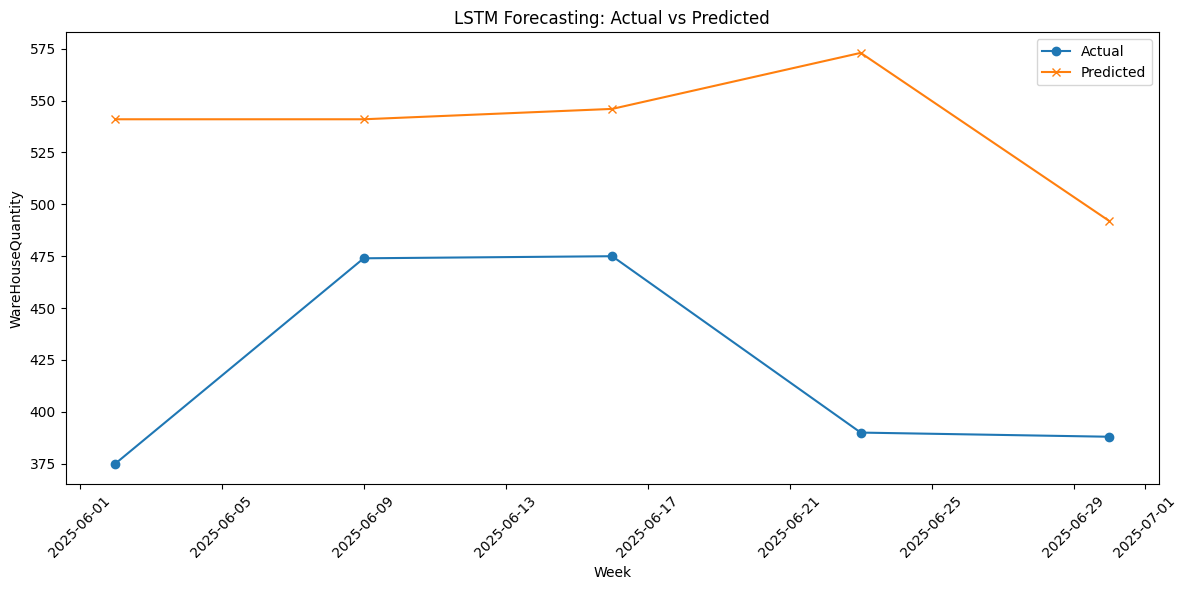

In [58]:
plt.figure(figsize=(12, 6))
plt.plot(result_df['Start_Week'], result_df['Actual_WareHouseQuantity'], label='Actual', marker='o')
plt.plot(result_df['Start_Week'], result_df['Predicted_WareHouseQuantity'], label='Predicted', marker='x')
plt.xticks(rotation=45)
plt.title('LSTM Forecasting: Actual vs Predicted')
plt.xlabel('Week')
plt.ylabel('WareHouseQuantity')
plt.legend()
plt.tight_layout()
plt.show()


### Using `activation='mish', batch_size=64, sequence_length=18`

In [59]:
import pandas as pd
import numpy as np
import tensorflow as tf
import random
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# ----------------------- STEP 0: Set Random Seed -----------------------
def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)

set_seed(42)

# ----------------------- STEP 1: Prepare Data -----------------------
df = pd.concat([train_data, test_data]).reset_index(drop=True)

# Normalize target
scaler = MinMaxScaler()
scaled_quantity = scaler.fit_transform(df[['WareHouseQuantity']])

# ----------------------- STEP 2: Create Sequences -----------------------
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)

sequence_length = 10
X_all, y_all = create_sequences(scaled_quantity, sequence_length)

X_train = X_all[:len(train_data) - sequence_length]
y_train = y_all[:len(train_data) - sequence_length]
X_test = X_all[len(train_data) - sequence_length:]
y_test = y_all[len(train_data) - sequence_length:]

# Reshape for LSTM
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# ----------------------- STEP 3: Build Model -----------------------
model = Sequential()
model.add(LSTM(192, input_shape=(sequence_length, 1)))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))  # Linear activation for regression

# ----------------------- STEP 4: Compile -----------------------
optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

# ----------------------- STEP 5: Callbacks -----------------------
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=10, factor=0.5, min_lr=1e-6, verbose=1)

# ----------------------- STEP 6: Train Model -----------------------
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ----------------------- STEP 7: Predict -----------------------
y_pred_scaled = model.predict(X_test, verbose=0)
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_test.reshape(-1, 1))

# ----------------------- STEP 8: Evaluation -----------------------
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
print("R2 Score:", r2_score(y_true, y_pred))

# ----------------------- STEP 9: Result DataFrame -----------------------
start_weeks = test_data['Week_Start'].iloc[:len(y_true)].reset_index(drop=True)
end_weeks = test_data['Week_End'].iloc[:len(y_true)].reset_index(drop=True)

actuals = pd.Series(y_true.flatten()).reset_index(drop=True)
predicted = pd.Series(np.round(y_pred.flatten()).astype(int)).reset_index(drop=True)
difference = predicted - actuals
percent_diff = ((difference / actuals) * 100).round(2)
minus_10 = (actuals * 0.9).round(2)
plus_10 = (actuals * 1.1).round(2)
within_10 = (predicted >= minus_10) & (predicted <= plus_10)
status = within_10.map({True: "Acceptable", False: "Out of Range"})

result_df = pd.DataFrame({
    'Start_Week': start_weeks,
    'End_Week': end_weeks,
    'Actual_WareHouseQuantity': actuals,
    'Predicted_WareHouseQuantity': predicted,
    'Difference_Between_Predicted_And_Actual': difference,
    'Percent_Difference': percent_diff,
    'Minus_10_Percent': minus_10,
    'Plus_10_Percent': plus_10,
    'Within_10_Percent': status
})

accuracy_within_10 = (result_df['Within_10_Percent'] == 'Acceptable').mean() * 100
print(f"\nAccuracy within ±10% of predicted values: {accuracy_within_10:.2f}%")

# Optionally save model and results
# model.save("best_lstm_model.h5")
# result_df.to_csv("best_model_results.csv", index=False)

# Return result
result_df


Epoch 1/200


c:\forecasting\workspace2\forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0576 - mae: 0.1803 - val_loss: 0.0154 - val_mae: 0.1182 - learning_rate: 1.0000e-04
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0441 - mae: 0.1435 - val_loss: 0.0077 - val_mae: 0.0792 - learning_rate: 1.0000e-04
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0339 - mae: 0.1135 - val_loss: 0.0029 - val_mae: 0.0441 - learning_rate: 1.0000e-04
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0268 - mae: 0.0987 - val_loss: 0.0018 - val_mae: 0.0325 - learning_rate: 1.0000e-04
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0234 - mae: 0.0998 - val_loss: 0.0038 - val_mae: 0.0511 - learning_rate: 1.0000e-04
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0227 - mae: 0.1056 - val_loss: 0.0055 - val_mae: 0.0637 - learning_rate: 1.0000e-04
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0226 - mae: 0.1083 - val_loss: 0.0053 - val_mae: 0.0623 - learning_rate: 1.0000e-04
Epoc

,Start_Week,End_Week,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
0,2025-06-02,2025-06-08,375.0,452,77.0,20.53,337.5,412.5,Out of Range
1,2025-06-09,2025-06-15,474.0,436,-38.0,-8.02,426.6,521.4,Acceptable
2,2025-06-16,2025-06-22,475.0,433,-42.0,-8.84,427.5,522.5,Acceptable
3,2025-06-23,2025-06-29,390.0,425,35.0,8.97,351.0,429.0,Acceptable
4,2025-06-30,2025-07-06,388.0,422,34.0,8.76,349.2,426.8,Acceptable
